<a href="https://colab.research.google.com/github/noobarafat/Global_Diabetes_Mortality_Analysis-IEEE_CSDE_2026_5586-/blob/main/IEEE_CSDE_2026_5586.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Diabetes Mortality Analysis (2000-2014)
Reproducible analysis pipeline for: *Global Diabetes Mortality Analysis: A Reproducible WHO Data-Driven Study of Trends, Regional Disparities, and Prevalence-Mortality Relationships (2000-2014)*

**Data sources:** WHO Global Health Estimates (GHE) 2021, WHO Global Health Observatory (GHO), accessed via Our World in Data.

This notebook regenerates every table, figure, and statistic reported in the paper. The single most important preprocessing step is removing the `World` aggregate row (Code: `OWID_WRL`) before any calculation, since it contains the global sum of all country deaths and otherwise silently double-counts every observation.

In [ ]:
from google.colab import files

print("Select deaths-from-diabetes-ghe.zip and diabetes-prevalence-who-gho.zip")
uploaded = files.upload()

Select deaths-from-diabetes-ghe.zip and diabetes-prevalence-who-gho.zip


Saving deaths-from-diabetes-ghe.zip to deaths-from-diabetes-ghe.zip
Saving diabetes-prevalence-who-gho.zip to diabetes-prevalence-who-gho.zip


In [ ]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

plt.rcParams.update({
    'font.size': 11, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False, 'axes.spines.right': False
})

## 1. Load and merge datasets

In [ ]:
with zipfile.ZipFile('/content/deaths-from-diabetes-ghe.zip', 'r') as z:
    z.extractall('/content/')
with zipfile.ZipFile('/content/diabetes-prevalence-who-gho.zip', 'r') as z:
    z.extractall('/content/')

ghe = pd.read_csv('/content/deaths-from-diabetes-ghe.csv')
gho = pd.read_csv('/content/diabetes-prevalence-who-gho.csv')
ghe.columns = ['Entity', 'Code', 'Year', 'Deaths']
gho.columns = ['Entity', 'Code', 'Year', 'Prevalence']

merged = pd.merge(ghe, gho, on=['Entity', 'Code', 'Year'], how='inner')
merged = merged[(merged['Year'] >= 2000) & (merged['Year'] <= 2014)]
merged = merged.dropna()

## 2. Remove the aggregate row (critical step)
`World` (Code `OWID_WRL`) is the global sum of all countries. Keeping it in descriptive statistics or correlation analysis silently double-counts every observation and inflated the reported maximum death count roughly fivefold in an earlier draft of this analysis. It is excluded here before anything else runs.

In [ ]:
AGGREGATES = ['World']
df = merged[~merged['Entity'].isin(AGGREGATES)].copy()

print(f'Countries: {df["Entity"].nunique()}')
print(f'Country-year observations: {len(df)}')
print(f'Missing values: {df.isnull().sum().sum()}')

Countries: 190
Country-year observations: 2850
Missing values: 0


## Data Quality Diagnostics
This section documents the checks that identified the aggregate-row issue before it was excluded above, and quantifies its effect on the descriptive statistics. Kept here for transparency rather than deleted once the fix was applied, since a reviewer reading only the clean numbers cannot verify the correction was necessary or correctly scoped.

### Diagnostic 1 - Identifying non-country rows
Our World in Data includes continent, income-group, and world-total rows in the same file as individual countries, distinguished by non-standard entity codes (e.g. OWID_WRL for World). These must be found and excluded before any descriptive statistic or correlation is computed on merged.

In [ ]:
non_standard_codes = merged[merged['Code'].str.len() != 3]['Entity'].unique()
print('Entities with non-ISO-3166 codes (likely aggregates):')
print(non_standard_codes.tolist())

world_row = merged[merged['Entity'] == 'World']
world_2014 = world_row[world_row['Year']==2014]['Deaths'].values[0]
india_2014 = merged[(merged['Entity']=='India') & (merged['Year']==2014)]['Deaths'].values[0]
print(f"\n'World' row appears in {len(world_row)} year-observations")
print(f"'World' deaths in 2014: {world_2014:,.2f}")
print(f"Highest true country value (India) in 2014: {india_2014:,.2f}")

Entities with non-ISO-3166 codes (likely aggregates):
['World']

'World' row appears in 15 year-observations
'World' deaths in 2014: 1,251,161.00
Highest true country value (India) in 2014: 248,179.62


### Diagnostic 2 - Quantifying the effect of including the aggregate row
Direct before/after comparison of the descriptive statistics that would be reported if the World row were left in, versus the corrected statistics used throughout this paper.

In [ ]:
desc_with_aggregate = merged[['Deaths', 'Prevalence']].describe()
desc_without_aggregate = df[['Deaths', 'Prevalence']].describe()

comparison = pd.DataFrame({
    'With World row (incorrect)': desc_with_aggregate['Deaths'],
    'Without World row (correct, used in paper)': desc_without_aggregate['Deaths']
})
print(comparison)

max_ratio = desc_with_aggregate['Deaths']['max'] / desc_without_aggregate['Deaths']['max']
mean_ratio = desc_with_aggregate['Deaths']['mean'] / desc_without_aggregate['Deaths']['mean']
print(f"\nMaximum inflated by {max_ratio:.1f}x when the aggregate row is left in")
print(f"Mean inflated by {mean_ratio:.2f}x")

       With World row (incorrect)  Without World row (correct, used in paper)
count                2.865000e+03                                 2850.000000
mean                 1.070397e+04                                 5373.405189
std                  7.604826e+04                                17373.471978
min                  2.300000e+00                                    2.300000
25%                  3.022500e+02                                  298.390000
50%                  1.208770e+03                                 1202.660000
75%                  3.183400e+03                                 3154.467500
max                  1.251161e+06                               248179.620000

Maximum inflated by 5.0x when the aggregate row is left in
Mean inflated by 1.99x


### Diagnostic 3 - Effect on the Pearson correlation itself
The aggregate row does not just distort Table II; leaving it in also changes the correlation coefficient and its statistical significance, since it introduces one wildly influential data point per year.

In [ ]:
r_with, p_with = stats.pearsonr(merged['Prevalence'], merged['Deaths'])
r_without, p_without = stats.pearsonr(df['Prevalence'], df['Deaths'])

print(f'With World row:    r = {r_with:.4f}, p = {p_with:.4f}')
print(f'Without World row: r = {r_without:.4f}, p = {p_without:.4f}')
print()
print('Note the p-value crosses the 0.05 significance threshold depending on')
print('whether the aggregate row is included, underscoring why this check')
print('matters for the validity of the reported result.')

With World row:    r = -0.0320, p = 0.0863
Without World row: r = -0.0619, p = 0.0009

Note the p-value crosses the 0.05 significance threshold depending on
whether the aggregate row is included, underscoring why this check
matters for the validity of the reported result.


## 3. Table II — Descriptive Statistics

In [ ]:
desc = df[['Deaths', 'Prevalence']].describe()
print(desc)

print(f"\nMean deaths: {df['Deaths'].mean():.2f}")
print(f"Median deaths: {df['Deaths'].median():.2f}")
print(f"Std deaths: {df['Deaths'].std():.2f}")
print(f"Min deaths: {df['Deaths'].min():.2f}")
print(f"Max deaths: {df['Deaths'].max():.2f}")
print(f"Total countries: {df['Entity'].nunique()}")

              Deaths   Prevalence
count    2850.000000  2850.000000
mean     5373.405189     8.693193
std     17373.471978     4.218448
min         2.300000     2.700000
25%       298.390000     6.200000
50%      1202.660000     7.400000
75%      3154.467500     9.900000
max    248179.620000    29.800000

Mean deaths: 5373.41
Median deaths: 1202.66
Std deaths: 17373.47
Min deaths: 2.30
Max deaths: 248179.62
Total countries: 190


## Fig. 2 — Global Mortality Trend

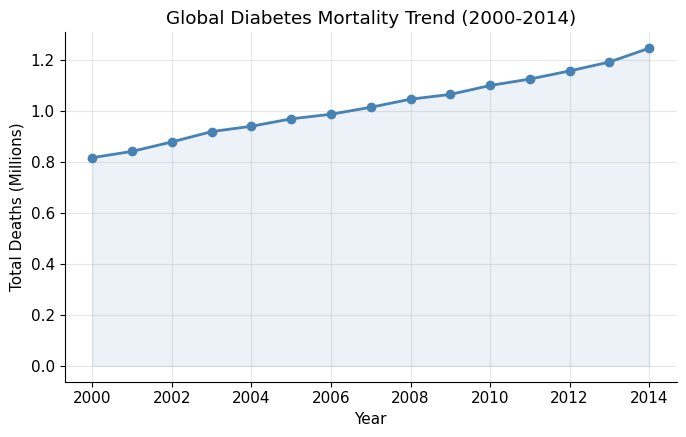

Deaths 2000: 817,646
Deaths 2014: 1,247,463
Total increase: 429,817 (52.6%)
CAGR: 3.06%


In [ ]:
global_trend = df.groupby('Year')['Deaths'].sum().reset_index()
global_trend['YoY'] = global_trend['Deaths'].pct_change() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(global_trend['Year'], global_trend['Deaths']/1e6, marker='o', color='steelblue', linewidth=2)
ax.fill_between(global_trend['Year'], global_trend['Deaths']/1e6, alpha=0.1, color='steelblue')
ax.set_xlabel('Year'); ax.set_ylabel('Total Deaths (Millions)')
ax.set_title('Global Diabetes Mortality Trend (2000-2014)')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout(); plt.savefig('fig2_global_trend.png', dpi=300, bbox_inches='tight'); plt.show()

d2000 = global_trend[global_trend['Year']==2000]['Deaths'].values[0]
d2014 = global_trend[global_trend['Year']==2014]['Deaths'].values[0]
cagr = ((d2014/d2000)**(1/14)-1)*100
print(f'Deaths 2000: {d2000:,.0f}')
print(f'Deaths 2014: {d2014:,.0f}')
print(f'Total increase: {d2014-d2000:,.0f} ({(d2014-d2000)/d2000*100:.1f}%)')
print(f'CAGR: {cagr:.2f}%')

## Fig. 3 — Year-over-Year Growth Rate

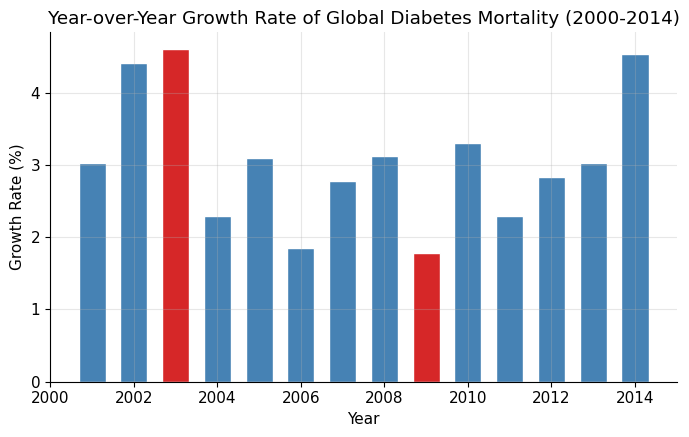

Min YoY: 1.78% (Year 2009)
Max YoY: 4.60% (Year 2003)


In [ ]:
yoy = global_trend.dropna(subset=['YoY'])
colors = ['#d62728' if v in (yoy['YoY'].max(), yoy['YoY'].min()) else 'steelblue' for v in yoy['YoY']]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(yoy['Year'], yoy['YoY'], color=colors, width=0.65, edgecolor='white')
ax.set_xlabel('Year'); ax.set_ylabel('Growth Rate (%)')
ax.set_title('Year-over-Year Growth Rate of Global Diabetes Mortality (2000-2014)')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout(); plt.savefig('fig3_yoy_growth.png', dpi=300, bbox_inches='tight'); plt.show()

print(f"Min YoY: {yoy['YoY'].min():.2f}% (Year {int(yoy.loc[yoy['YoY'].idxmin(),'Year'])})")
print(f"Max YoY: {yoy['YoY'].max():.2f}% (Year {int(yoy.loc[yoy['YoY'].idxmax(),'Year'])})")

## Fig. 4 — Top 10 Countries by Cumulative Mortality
Color-coded by World Bank income classification, the same classification used throughout Section IV and Table III.

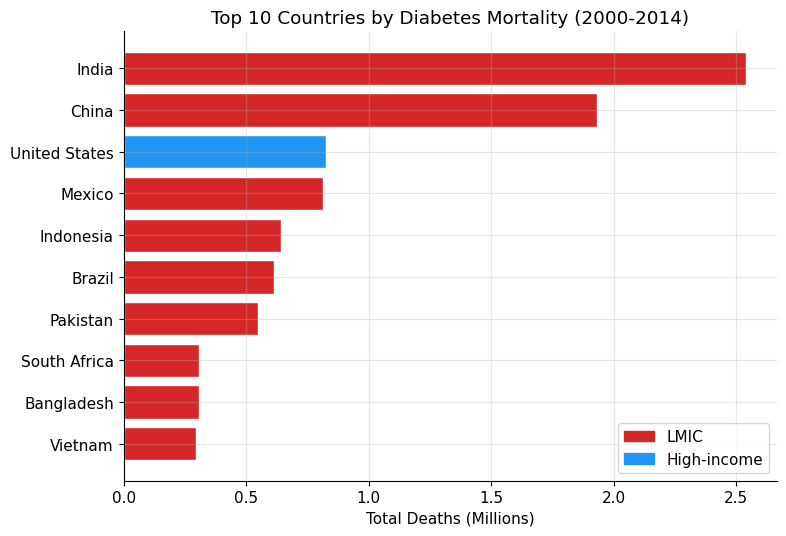

LMICs in top 10 (World Bank classification): 9 of 10
India + China share of top-10 cumulative deaths: 51%


In [ ]:
high_income_list = ['United States','Germany','France','United Kingdom','Japan','Canada',
    'Australia','Italy','Spain','Netherlands','Belgium','Sweden','Austria','Switzerland',
    'Norway','Denmark','Finland','South Korea','Singapore','New Zealand','Ireland',
    'Luxembourg','Iceland','Malta','Andorra','Cyprus','Israel','Kuwait','Qatar',
    'Bahrain','United Arab Emirates','Brunei','Cook Islands']

cumulative = df.groupby('Entity')['Deaths'].sum().sort_values(ascending=False)
top10 = cumulative.head(10)
colors4 = ['#2196F3' if c in high_income_list else '#d62728' for c in top10.index[::-1]]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top10.index[::-1], top10.values[::-1]/1e6, color=colors4, edgecolor='white')
ax.set_xlabel('Total Deaths (Millions)')
ax.set_title('Top 10 Countries by Diabetes Mortality (2000-2014)')
ax.legend(handles=[mpatches.Patch(color='#d62728', label='LMIC'),
                    mpatches.Patch(color='#2196F3', label='High-income')], loc='lower right')
plt.tight_layout(); plt.savefig('fig4_top10.png', dpi=300, bbox_inches='tight'); plt.show()

n_lmic_top10 = sum(1 for c in top10.index if c not in high_income_list)
print(f'LMICs in top 10 (World Bank classification): {n_lmic_top10} of 10')
india_china_share = (top10['India'] + top10['China']) / top10.sum() * 100
print(f'India + China share of top-10 cumulative deaths: {india_china_share:.0f}%')

## Fig. 5 — Regional Analysis
Total deaths summed within each continental region for a given year, then averaged across the 15-year period. All 190 countries are mapped by ISO 3166-1 standard continental assignment; no exclusions beyond the single aggregate row removed in Step 2. Note: these are continental groupings defined for this analysis, not official WHO administrative regions.

In [ ]:
region_map = {
    'Asia': ['India','China','Indonesia','Pakistan','Bangladesh','Vietnam','Philippines',
        'Thailand','Myanmar','Japan','South Korea','Malaysia','Nepal','Sri Lanka','Cambodia',
        'Afghanistan','Iran','Iraq','Saudi Arabia','Turkey','Uzbekistan','Kazakhstan',
        'Azerbaijan','Syria','Yemen','Jordan','Israel','Lebanon','Oman','Kuwait','Qatar',
        'Bahrain','United Arab Emirates','Mongolia','Kyrgyzstan','Tajikistan','Turkmenistan',
        'Georgia','Armenia','Cyprus','East Timor','Bhutan','Maldives','Brunei','Singapore',
        'Laos','North Korea','Micronesia (country)','Nauru','Niue','Palau','Tuvalu'],
    'Africa': ['Nigeria','South Africa','Ethiopia','Egypt','Kenya','Tanzania','Sudan','Uganda',
        'Ghana','Mozambique','Madagascar','Angola','Cameroon','Zimbabwe','Senegal','Zambia',
        'Tunisia','Somalia','Rwanda','Chad','Niger','Mali','Burkina Faso','Guinea','Malawi',
        'South Sudan','Sierra Leone','Togo','Libya','Congo','Eritrea','Mauritania','Benin',
        'Burundi','Liberia','Central African Republic','Gabon','Lesotho','Gambia','Botswana',
        'Namibia','Mauritius','Djibouti','Equatorial Guinea','Comoros','Cape Verde','Seychelles',
        "Cote d'Ivoire",'Democratic Republic of Congo','Algeria','Eswatini','Guinea-Bissau',
        'Morocco','Sao Tome and Principe'],
    'North America': ['United States','Mexico','Canada','Cuba','Guatemala','Haiti',
        'Dominican Republic','Honduras','El Salvador','Nicaragua','Costa Rica','Panama',
        'Jamaica','Trinidad and Tobago','Barbados','Belize','Bahamas','Saint Lucia','Grenada',
        'Antigua and Barbuda','Dominica','Saint Kitts and Nevis','Saint Vincent and the Grenadines'],
    'Europe': ['Germany','France','United Kingdom','Italy','Spain','Poland','Netherlands',
        'Belgium','Sweden','Austria','Switzerland','Norway','Denmark','Finland','Portugal',
        'Greece','Czechia','Romania','Hungary','Bulgaria','Slovakia','Croatia','Serbia',
        'Ukraine','Russia','Belarus','Lithuania','Latvia','Estonia','Slovenia','Luxembourg',
        'Ireland','Iceland','Malta','Montenegro','Albania','North Macedonia',
        'Bosnia and Herzegovina','Moldova','Kosovo','Andorra'],
    'South America': ['Brazil','Colombia','Argentina','Chile','Peru','Venezuela','Ecuador',
        'Bolivia','Paraguay','Uruguay','Guyana','Suriname'],
    'Oceania': ['Australia','New Zealand','Papua New Guinea','Fiji','Solomon Islands','Vanuatu',
        'Samoa','Kiribati','Tonga','Marshall Islands','Cook Islands']
}
df['Region'] = None
for region, countries in region_map.items():
    df.loc[df['Entity'].isin(countries), 'Region'] = region

print(f"Unmapped entities: {df[df['Region'].isna()]['Entity'].unique().tolist()}")

Unmapped entities: []


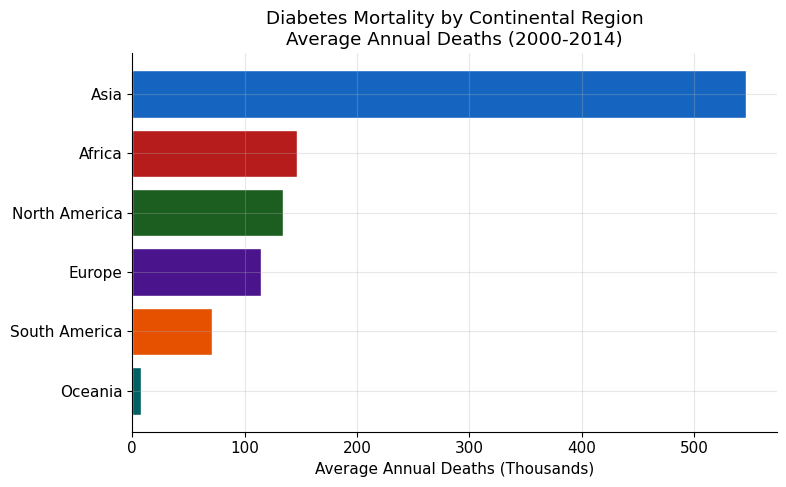

Asia: 546,678
Africa: 146,357
North America: 134,436
Europe: 114,497
South America: 71,065
Oceania: 7,916
Asia exceeds sum of other five regions: True
Asia CAGR: 3.74%
Africa CAGR: 3.80%
North America CAGR: 1.82%
Europe CAGR: 0.86%
South America CAGR: 2.37%
Oceania CAGR: 2.83%


In [ ]:
regional_yearly_sum = df.groupby(['Region', 'Year'])['Deaths'].sum().reset_index()
regional_avg = regional_yearly_sum.groupby('Region')['Deaths'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
palette = ['#1565C0','#B71C1C','#1B5E20','#4A148C','#E65100','#006064']
ax.barh(regional_avg.index[::-1], regional_avg.values[::-1]/1e3, color=palette[::-1], edgecolor='white')
ax.set_xlabel('Average Annual Deaths (Thousands)')
ax.set_title('Diabetes Mortality by Continental Region\nAverage Annual Deaths (2000-2014)')
plt.tight_layout(); plt.savefig('fig5_regional.png', dpi=300, bbox_inches='tight'); plt.show()

for r, v in regional_avg.items():
    print(f'{r}: {v:,.0f}')
print(f'Asia exceeds sum of other five regions: {regional_avg.iloc[0] > regional_avg.iloc[1:].sum()}')

for region in regional_avg.index:
    sub = regional_yearly_sum[regional_yearly_sum['Region']==region]
    d0 = sub[sub['Year']==2000]['Deaths'].values[0]
    d14 = sub[sub['Year']==2014]['Deaths'].values[0]
    r_cagr = ((d14/d0)**(1/14)-1)*100
    print(f'{region} CAGR: {r_cagr:.2f}%')

### Fig. 6 — Prevalence vs Mortality Correlation (Pearson + Spearman)

In [ ]:
r, p = stats.pearsonr(df['Prevalence'], df['Deaths'])
X = df[['Prevalence']].values
y = df['Deaths'].values
model = LinearRegression().fit(X, y)
x_line = np.linspace(df['Prevalence'].min(), df['Prevalence'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

r_rate, p_rate = stats.pearsonr(df_pop['Prevalence'], df_pop['Deaths_per_100k'])
X2 = df_pop[['Prevalence']].values
y2 = df_pop['Deaths_per_100k'].values
model2 = LinearRegression().fit(X2, y2)
x_line2 = np.linspace(df_pop['Prevalence'].min(), df_pop['Prevalence'].max(), 100)
y_line2 = model2.predict(x_line2.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['Prevalence'], df['Deaths']/1e6, alpha=0.25, s=8, color='steelblue')
axes[0].plot(x_line, y_line/1e6, color='red', linewidth=1.5, label=f'r={r:.3f}')
axes[0].set_xlabel('Prevalence (%)')
axes[0].set_ylabel('Total Deaths (Millions)')
axes[0].set_title('(a) Raw Death Counts\n(confounded by population size)')
axes[0].legend()

axes[1].scatter(df_pop['Prevalence'], df_pop['Deaths_per_100k'], alpha=0.25, s=8, color='#6A1B9A')
axes[1].plot(x_line2, y_line2, color='red', linewidth=1.5, label=f'r={r_rate:.3f}')
axes[1].set_xlabel('Prevalence (%)')
axes[1].set_ylabel('Deaths per 100,000 Population')
axes[1].set_title('(b) Population-Normalized Rate\n(controls for population size)')
axes[1].legend()

fig.suptitle('Correlation between Diabetes Prevalence and Mortality (2000-2014)', y=1.02)
plt.tight_layout()
plt.savefig('paper_outputs/fig6_correlation_combined.png', dpi=300, bbox_inches='tight')
plt.close()

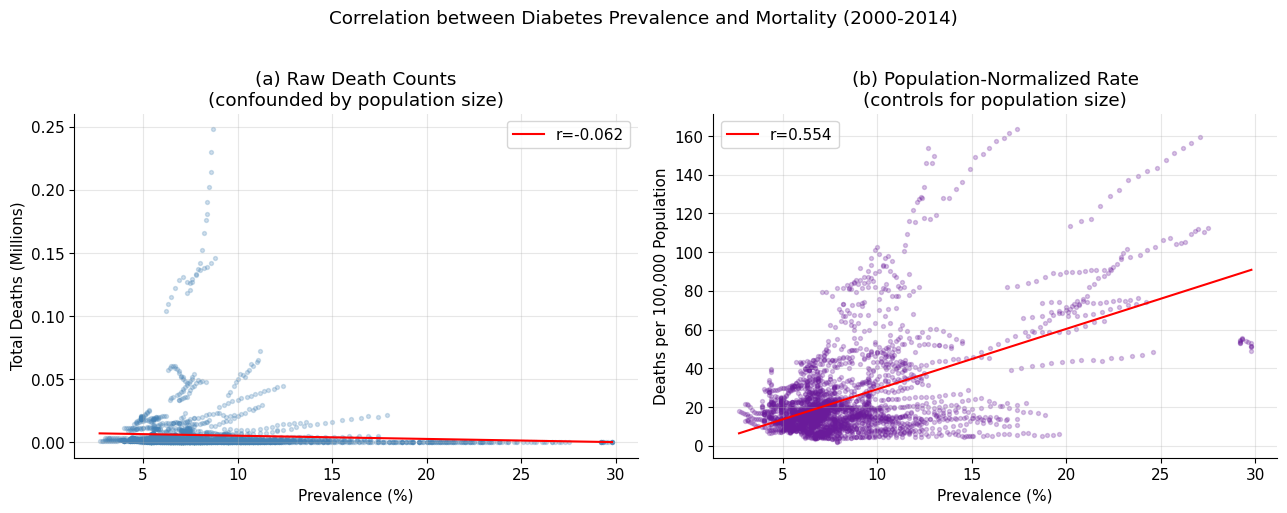

Raw deaths:    r = -0.0619, p = 0.000947
Rate per 100k: r = 0.5535, p = 0.000000


In [ ]:
r, p = stats.pearsonr(df['Prevalence'], df['Deaths'])
X = df[['Prevalence']].values
y = df['Deaths'].values
model = LinearRegression().fit(X, y)
x_line = np.linspace(df['Prevalence'].min(), df['Prevalence'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

r_rate, p_rate = stats.pearsonr(df_pop['Prevalence'], df_pop['Deaths_per_100k'])
X2 = df_pop[['Prevalence']].values
y2 = df_pop['Deaths_per_100k'].values
model2 = LinearRegression().fit(X2, y2)
x_line2 = np.linspace(df_pop['Prevalence'].min(), df_pop['Prevalence'].max(), 100)
y_line2 = model2.predict(x_line2.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['Prevalence'], df['Deaths']/1e6, alpha=0.25, s=8, color='steelblue')
axes[0].plot(x_line, y_line/1e6, color='red', linewidth=1.5, label=f'r={r:.3f}')
axes[0].set_xlabel('Prevalence (%)')
axes[0].set_ylabel('Total Deaths (Millions)')
axes[0].set_title('(a) Raw Death Counts\n(confounded by population size)')
axes[0].legend()

axes[1].scatter(df_pop['Prevalence'], df_pop['Deaths_per_100k'], alpha=0.25, s=8, color='#6A1B9A')
axes[1].plot(x_line2, y_line2, color='red', linewidth=1.5, label=f'r={r_rate:.3f}')
axes[1].set_xlabel('Prevalence (%)')
axes[1].set_ylabel('Deaths per 100,000 Population')
axes[1].set_title('(b) Population-Normalized Rate\n(controls for population size)')
axes[1].legend()

fig.suptitle('Correlation between Diabetes Prevalence and Mortality (2000-2014)', y=1.02)
plt.tight_layout()
plt.savefig('fig6_correlation_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Raw deaths:    r = {r:.4f}, p = {p:.6f}")
print(f"Rate per 100k: r = {r_rate:.4f}, p = {p_rate:.6f}")

## Fig. 7 — Top 5 Countries Mortality Trend

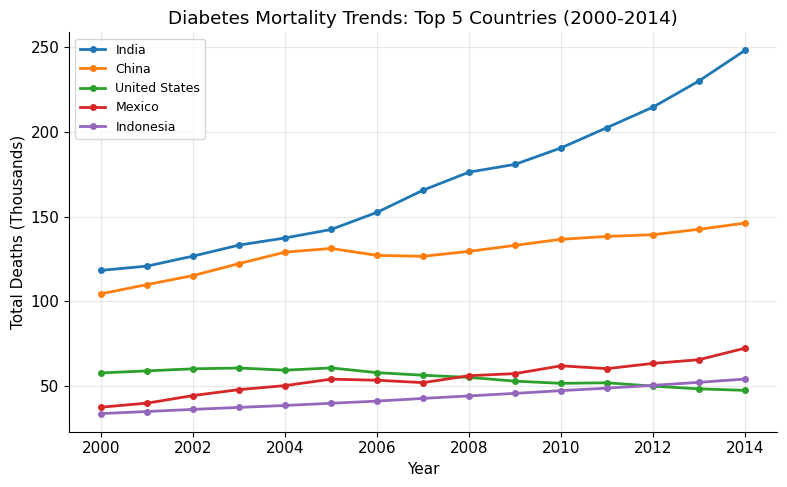

India: 118,189 -> 248,180 (+110%), CAGR 5.44%
China: 104,347 -> 146,117 (+40%), CAGR 2.43%
United States: 57,547 -> 47,233 (-18%), CAGR -1.40%
Mexico: 37,289 -> 72,139 (+93%), CAGR 4.83%
Indonesia: 33,515 -> 53,909 (+61%), CAGR 3.45%


In [ ]:
top5 = cumulative.head(5).index.tolist()
colors5 = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, ax = plt.subplots(figsize=(8, 5))
for i, country in enumerate(top5):
    sub = df[df['Entity']==country].sort_values('Year')
    ax.plot(sub['Year'], sub['Deaths']/1e3, marker='o', markersize=4, label=country,
            color=colors5[i], linewidth=2)
ax.set_xlabel('Year'); ax.set_ylabel('Total Deaths (Thousands)')
ax.set_title('Diabetes Mortality Trends: Top 5 Countries (2000-2014)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout(); plt.savefig('fig7_top5_trend.png', dpi=300, bbox_inches='tight'); plt.show()

for country in top5:
    sub = df[df['Entity']==country].sort_values('Year')
    ds = sub[sub['Year']==2000]['Deaths'].values[0]
    de = sub[sub['Year']==2014]['Deaths'].values[0]
    country_cagr = ((de/ds)**(1/14)-1)*100
    print(f'{country}: {ds:,.0f} -> {de:,.0f} ({(de-ds)/ds*100:+.0f}%), CAGR {country_cagr:.2f}%')

## Sensitivity 1 — Annual cross-sectional Pearson correlation
Addresses non-independence of repeated country-year observations: checks whether the pooled correlation is driven by any single year.

In [ ]:
yearly_r = []
for yr in range(2000, 2015):
    sub = df[df['Year']==yr]
    r_yr, p_yr = stats.pearsonr(sub['Prevalence'], sub['Deaths'])
    yearly_r.append(r_yr)
    print(f'{yr}: r = {r_yr:.4f}, p = {p_yr:.4f}, n = {len(sub)}')

print(f'\nMean annual r: {np.mean(yearly_r):.4f}')
print(f'Max |r| across years: {max(abs(v) for v in yearly_r):.4f}')

2000: r = -0.0793, p = 0.2766, n = 190
2001: r = -0.0790, p = 0.2784, n = 190
2002: r = -0.0778, p = 0.2860, n = 190
2003: r = -0.0752, p = 0.3024, n = 190
2004: r = -0.0734, p = 0.3141, n = 190
2005: r = -0.0732, p = 0.3154, n = 190
2006: r = -0.0710, p = 0.3303, n = 190
2007: r = -0.0700, p = 0.3369, n = 190
2008: r = -0.0689, p = 0.3450, n = 190
2009: r = -0.0669, p = 0.3590, n = 190
2010: r = -0.0658, p = 0.3673, n = 190
2011: r = -0.0652, p = 0.3718, n = 190
2012: r = -0.0636, p = 0.3836, n = 190
2013: r = -0.0639, p = 0.3811, n = 190
2014: r = -0.0611, p = 0.4021, n = 190

Mean annual r: -0.0703
Max |r| across years: 0.0793


## Sensitivity 2 — Country-level average correlation (n=190)
Collapses each country to its 15-year average, removing within-country repetition entirely.

In [ ]:
country_avg = df.groupby('Entity').agg(Deaths=('Deaths','mean'), Prevalence=('Prevalence','mean')).reset_index()
r_c, p_c = stats.pearsonr(country_avg['Prevalence'], country_avg['Deaths'])
rho_c, p_rho_c = stats.spearmanr(country_avg['Prevalence'], country_avg['Deaths'])
print(f'N = {len(country_avg)} countries')
print(f'Pearson r = {r_c:.4f}, p = {p_c:.4f}')
print(f'Spearman rho = {rho_c:.4f}, p = {p_rho_c:.4f}')

N = 190 countries
Pearson r = -0.0702, p = 0.3355
Spearman rho = -0.3436, p = 0.0000


## Sensitivity 3 — Excluding India and China
Checks whether the two largest outlier countries drive the pooled result.

In [ ]:
df_ex = df[~df['Entity'].isin(['India', 'China'])]
r_ex, p_ex = stats.pearsonr(df_ex['Prevalence'], df_ex['Deaths'])
rho_ex, p_rho_ex = stats.spearmanr(df_ex['Prevalence'], df_ex['Deaths'])
print(f'N = {len(df_ex)} observations, {df_ex["Entity"].nunique()} countries')
print(f'Pearson r = {r_ex:.4f}, p = {p_ex:.4f}')
print(f'Spearman rho = {rho_ex:.4f}, p = {p_rho_ex:.4f}')

N = 2820 observations, 188 countries
Pearson r = -0.0960, p = 0.0000
Spearman rho = -0.3283, p = 0.0000


## Two-way Fixed-Effects Panel Regression
Controls for both country-level and year-level unobserved heterogeneity using the within estimator, with country-clustered standard errors. This directly addresses the non-independence of repeated country-year observations.

In [ ]:
d = df.copy()
d['Deaths_tilde'] = d['Deaths'] - d.groupby('Entity')['Deaths'].transform('mean') \
                     - d.groupby('Year')['Deaths'].transform('mean') + d['Deaths'].mean()
d['Prevalence_tilde'] = d['Prevalence'] - d.groupby('Entity')['Prevalence'].transform('mean') \
                        - d.groupby('Year')['Prevalence'].transform('mean') + d['Prevalence'].mean()

X_fe = sm.add_constant(d['Prevalence_tilde'])
fe_model = sm.OLS(d['Deaths_tilde'], X_fe).fit(cov_type='cluster', cov_kwds={'groups': d['Entity']})
print(fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Deaths_tilde   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.05550
Date:                Sun, 20 Sep 2026   Prob (F-statistic):              0.814
Time:                        10:00:02   Log-Likelihood:                -27063.
No. Observations:                2850   AIC:                         5.413e+04
Df Residuals:                    2848   BIC:                         5.414e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.791e-13   5.02e-14  

## Income-Group Analysis with Bootstrap Confidence Intervals
Classification: World Bank income groups (fixed list, applied uniformly across 2000-2014). CAGR point estimates are supplemented with 95% bootstrap confidence intervals (country-resampled, 2000 iterations) to quantify sampling uncertainty in the group-level trends.

In [ ]:
df['IncomeGroup'] = df['Entity'].apply(lambda x: 'High-income' if x in high_income_list else 'LMIC')

def bootstrap_cagr(sub_df, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    entities = sub_df['Entity'].unique()
    yearly = sub_df.groupby(['Entity','Year'])['Deaths'].sum().reset_index()
    cagrs = []
    for _ in range(n_boot):
        sample = rng.choice(entities, size=len(entities), replace=True)
        boot = pd.concat([yearly[yearly['Entity']==e] for e in sample])
        totals = boot.groupby('Year')['Deaths'].sum()
        if 2000 in totals.index and 2014 in totals.index and totals[2000] > 0:
            cagrs.append(((totals[2014]/totals[2000])**(1/14)-1)*100)
    return np.mean(cagrs), np.percentile(cagrs, [2.5, 97.5])

for label, sub in [('Global', df), ('High-income', df[df['IncomeGroup']=='High-income']),
                    ('LMIC', df[df['IncomeGroup']=='LMIC'])]:
    mean_cagr, ci = bootstrap_cagr(sub)
    print(f'{label}: CAGR point estimate ~{mean_cagr:.2f}%, 95% CI [{ci[0]:.2f}%, {ci[1]:.2f}%]')

print(f"\nHigh-income countries: {df[df['IncomeGroup']=='High-income']['Entity'].nunique()}")
print(f"LMIC countries: {df[df['IncomeGroup']=='LMIC']['Entity'].nunique()}")

Global: CAGR point estimate ~3.01%, 95% CI [2.02%, 3.94%]
High-income: CAGR point estimate ~-0.48%, 95% CI [-1.06%, 0.28%]
LMIC: CAGR point estimate ~3.68%, 95% CI [2.92%, 4.44%]

High-income countries: 33
LMIC countries: 157


## Table III — Key Statistical Findings Summary

In [ ]:
print('Metric | Value')
print(f'Global Deaths (2000) | {d2000:,.0f}')
print(f'Global Deaths (2014) | {d2014:,.0f}')
print(f'Total Increase | {d2014-d2000:,.0f} (+{(d2014-d2000)/d2000*100:.1f}%)')
print(f'CAGR (2000-2014) | {cagr:.2f}%')
print(f'Pearson r | {r:.4f} (p = {p:.6f})')
print(f'Spearman rho | {rho:.4f} (p = {p_rho:.6f})')
print(f'R-squared | {r2:.4f}')

Metric | Value
Global Deaths (2000) | 817,646
Global Deaths (2014) | 1,247,463
Total Increase | 429,817 (+52.6%)
CAGR (2000-2014) | 3.06%
Pearson r | -0.0619 (p = 0.000947)
Spearman rho | -0.3200 (p = 0.000000)
R-squared | 0.0038


In [ ]:
from google.colab import files

print("Select population-unwpp.csv")
uploaded = files.upload()

Select population-unwpp.csv


Saving population-unwpp.csv to population-unwpp.csv


In [ ]:
pop = pd.read_csv('population-unwpp.csv')
pop.columns = ['Entity', 'Code', 'Year', 'Population']

df_pop = pd.merge(df, pop, on=['Entity', 'Code', 'Year'], how='left')

matched = df_pop['Population'].notna().sum()
total = len(df_pop)
print(f"Matched {matched} of {total} country-year observations ({matched/total*100:.1f}%)")

unmatched_entities = df_pop[df_pop['Population'].isna()]['Entity'].unique()
print(f"Unmatched entities: {list(unmatched_entities)}")

Matched 2850 of 2850 country-year observations (100.0%)
Unmatched entities: []


In [ ]:
df_pop = df_pop.dropna(subset=['Population']).copy()
df_pop['Deaths_per_100k'] = (df_pop['Deaths'] / df_pop['Population']) * 100000

print(df_pop['Deaths_per_100k'].describe())
print(f"\nMean: {df_pop['Deaths_per_100k'].mean():.2f} per 100,000")
print(f"Median: {df_pop['Deaths_per_100k'].median():.2f} per 100,000")

count    2850.000000
mean       25.093386
std        23.760110
min         1.875190
25%        11.685581
50%        17.260374
75%        28.169242
max       163.519833
Name: Deaths_per_100k, dtype: float64

Mean: 25.09 per 100,000
Median: 17.26 per 100,000


In [ ]:
r_rate, p_rate = stats.pearsonr(df_pop['Prevalence'], df_pop['Deaths_per_100k'])
rho_rate, p_rho_rate = stats.spearmanr(df_pop['Prevalence'], df_pop['Deaths_per_100k'])

print("=== Prevalence vs RAW deaths (original, confounded by population size) ===")
print(f"Pearson r = -0.0619, Spearman rho = -0.3200")

print("\n=== Prevalence vs deaths PER 100,000 (population-normalized) ===")
print(f"Pearson r = {r_rate:.4f}, p = {p_rate:.6f}")
print(f"Spearman rho = {rho_rate:.4f}, p = {p_rho_rate:.6f}")

=== Prevalence vs RAW deaths (original, confounded by population size) ===
Pearson r = -0.0619, Spearman rho = -0.3200

=== Prevalence vs deaths PER 100,000 (population-normalized) ===
Pearson r = 0.5535, p = 0.000000
Spearman rho = 0.2851, p = 0.000000


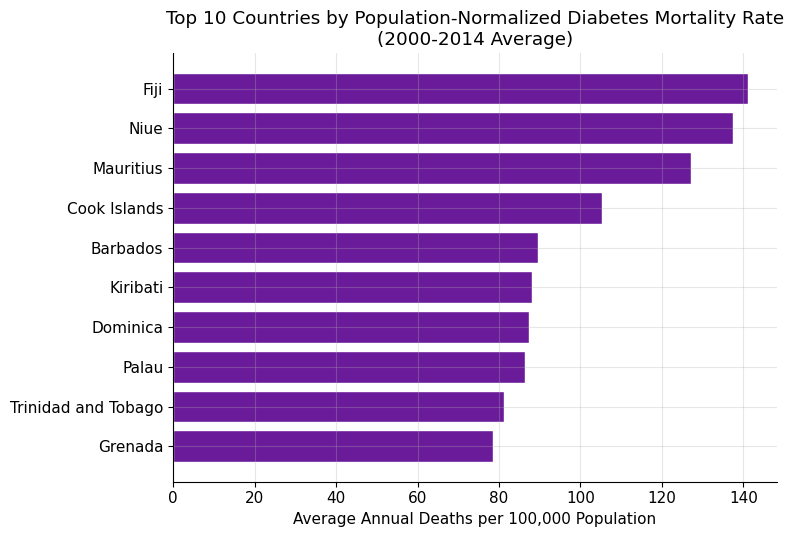

Top 10 by RAW count (original Fig. 4):
['India', 'China', 'United States', 'Mexico', 'Indonesia', 'Brazil', 'Pakistan', 'South Africa', 'Bangladesh', 'Vietnam']

Top 10 by RATE per 100,000 (new):
['Fiji', 'Niue', 'Mauritius', 'Cook Islands', 'Barbados', 'Kiribati', 'Dominica', 'Palau', 'Trinidad and Tobago', 'Grenada']


In [ ]:
rate_avg = df_pop.groupby('Entity')['Deaths_per_100k'].mean().sort_values(ascending=False)
top10_rate = rate_avg.head(10)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top10_rate.index[::-1], top10_rate.values[::-1], color='#6A1B9A', edgecolor='white')
ax.set_xlabel('Average Annual Deaths per 100,000 Population')
ax.set_title('Top 10 Countries by Population-Normalized Diabetes Mortality Rate\n(2000-2014 Average)')
plt.tight_layout()
plt.savefig('fig8_top10_rate.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 10 by RAW count (original Fig. 4):")
print(cumulative.head(10).index.tolist())
print("\nTop 10 by RATE per 100,000 (new):")
print(top10_rate.index.tolist())

In [ ]:
rate_ranks = rate_avg.rank(ascending=False)
count_ranks = cumulative.rank(ascending=False)

print("Country | Raw-count rank | Rate-per-100k rank")
for country in cumulative.head(10).index:
    if country in rate_ranks.index:
        print(f"{country}: #{int(count_ranks[country])} by count, #{int(rate_ranks[country])} by rate")

Country | Raw-count rank | Rate-per-100k rank
India: #1 by count, #125 by rate
China: #2 by count, #157 by rate
United States: #3 by count, #89 by rate
Mexico: #4 by count, #21 by rate
Indonesia: #5 by count, #90 by rate
Brazil: #6 by count, #67 by rate
Pakistan: #7 by count, #74 by rate
South Africa: #8 by count, #31 by rate
Bangladesh: #9 by count, #132 by rate
Vietnam: #10 by count, #59 by rate


In [ ]:
# Sensitivity: does the population-normalized correlation hold when
# excluding very small population countries, where per-capita rates
# are more statistically volatile?
df_pop_filtered = df_pop[df_pop['Population'] >= 1_000_000]

r_filtered, p_filtered = stats.pearsonr(df_pop_filtered['Prevalence'], df_pop_filtered['Deaths_per_100k'])
rho_filtered, p_rho_filtered = stats.spearmanr(df_pop_filtered['Prevalence'], df_pop_filtered['Deaths_per_100k'])

print(f"Excluding countries under 1 million population (n={len(df_pop_filtered)} obs, {df_pop_filtered['Entity'].nunique()} countries):")
print(f"Pearson r = {r_filtered:.4f}, p = {p_filtered:.6f}")
print(f"Spearman rho = {rho_filtered:.4f}, p = {p_rho_filtered:.6f}")

Excluding countries under 1 million population (n=2264 obs, 154 countries):
Pearson r = 0.1008, p = 0.000002
Spearman rho = -0.0123, p = 0.558029


In [ ]:
d_rate = df_pop.copy()
d_rate['Rate_tilde'] = d_rate['Deaths_per_100k'] - d_rate.groupby('Entity')['Deaths_per_100k'].transform('mean') \
                        - d_rate.groupby('Year')['Deaths_per_100k'].transform('mean') + d_rate['Deaths_per_100k'].mean()
d_rate['Prevalence_tilde_r'] = d_rate['Prevalence'] - d_rate.groupby('Entity')['Prevalence'].transform('mean') \
                        - d_rate.groupby('Year')['Prevalence'].transform('mean') + d_rate['Prevalence'].mean()

X_fe_rate = sm.add_constant(d_rate['Prevalence_tilde_r'])
fe_model_rate = sm.OLS(d_rate['Rate_tilde'], X_fe_rate).fit(cov_type='cluster', cov_kwds={'groups': d_rate['Entity']})
print(fe_model_rate.summary())

                            OLS Regression Results                            
Dep. Variable:             Rate_tilde   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     6.180
Date:                Sun, 20 Sep 2026   Prob (F-statistic):             0.0138
Time:                        10:18:47   Log-Likelihood:                -7790.7
No. Observations:                2850   AIC:                         1.559e+04
Df Residuals:                    2848   BIC:                         1.560e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               2.061e-15   1.96

In [ ]:
print("Dataset provenance and retrieval information:")
print()
print("1. WHO Global Health Estimates (GHE) 2021 — deaths")
print("   Source: Our World in Data")
print("   URL: https://ourworldindata.org/grapher/deaths-from-diabetes-ghe")
print("   Accessed: June 26, 2026")
print()
print("2. WHO Global Health Observatory (GHO) — prevalence")
print("   Source: Our World in Data")
print("   URL: https://ourworldindata.org/grapher/diabetes-prevalence-who-gho")
print("   Accessed: June 26, 2026")
print()
print("3. UN World Population Prospects 2024 — population")
print("   Source: Our World in Data")
print("   URL: https://ourworldindata.org/grapher/population-unwpp")
print("   Accessed: September 20, 2026")

Dataset provenance and retrieval information:

1. WHO Global Health Estimates (GHE) 2021 — deaths
   Source: Our World in Data
   URL: https://ourworldindata.org/grapher/deaths-from-diabetes-ghe
   Accessed: June 26, 2026

2. WHO Global Health Observatory (GHO) — prevalence
   Source: Our World in Data
   URL: https://ourworldindata.org/grapher/diabetes-prevalence-who-gho
   Accessed: June 26, 2026

3. UN World Population Prospects 2024 — population
   Source: Our World in Data
   URL: https://ourworldindata.org/grapher/population-unwpp
   Accessed: September 20, 2026


In [ ]:
import zipfile
import os

# ============================================================
# Ensure output folder exists
# ============================================================
os.makedirs('paper_outputs', exist_ok=True)

STYLE = {'figure.facecolor': 'white', 'axes.facecolor': 'white',
         'axes.grid': True, 'grid.alpha': 0.3,
         'axes.spines.top': False, 'axes.spines.right': False}
plt.rcParams.update(STYLE)
plt.rcParams['font.size'] = 11

# ============================================================
# Fig. 2 — Global Mortality Trend
# ============================================================
global_trend = df.groupby('Year')['Deaths'].sum().reset_index()
global_trend['YoY'] = global_trend['Deaths'].pct_change() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(global_trend['Year'], global_trend['Deaths']/1e6, marker='o', color='steelblue', linewidth=2)
ax.fill_between(global_trend['Year'], global_trend['Deaths']/1e6, alpha=0.1, color='steelblue')
ax.set_xlabel('Year'); ax.set_ylabel('Total Deaths (Millions)')
ax.set_title('Global Diabetes Mortality Trend (2000-2014)')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('paper_outputs/fig2_global_trend.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================================
# Fig. 3 — Year-over-Year Growth
# ============================================================
yoy = global_trend.dropna(subset=['YoY'])
colors3 = ['#d62728' if v in (yoy['YoY'].max(), yoy['YoY'].min()) else 'steelblue' for v in yoy['YoY']]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(yoy['Year'], yoy['YoY'], color=colors3, width=0.65, edgecolor='white')
ax.set_xlabel('Year'); ax.set_ylabel('Growth Rate (%)')
ax.set_title('Year-over-Year Growth Rate of Global Diabetes Mortality (2000-2014)')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('paper_outputs/fig3_yoy_growth.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================================
# Fig. 4 — Top 10 Countries (raw count, income-coded)
# ============================================================
high_income_list = ['United States','Germany','France','United Kingdom','Japan','Canada',
    'Australia','Italy','Spain','Netherlands','Belgium','Sweden','Austria','Switzerland',
    'Norway','Denmark','Finland','South Korea','Singapore','New Zealand','Ireland',
    'Luxembourg','Iceland','Malta','Andorra','Cyprus','Israel','Kuwait','Qatar',
    'Bahrain','United Arab Emirates','Brunei','Cook Islands']

cumulative = df.groupby('Entity')['Deaths'].sum().sort_values(ascending=False)
top10 = cumulative.head(10)
colors4 = ['#2196F3' if c in high_income_list else '#d62728' for c in top10.index[::-1]]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top10.index[::-1], top10.values[::-1]/1e6, color=colors4, edgecolor='white')
ax.set_xlabel('Total Deaths (Millions)')
ax.set_title('Top 10 Countries by Diabetes Mortality (2000-2014)')
ax.legend(handles=[mpatches.Patch(color='#d62728', label='LMIC'),
                    mpatches.Patch(color='#2196F3', label='High-income')], loc='lower right')
plt.tight_layout()
plt.savefig('paper_outputs/fig4_top10_count.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================================
# Fig. 5 — Regional Analysis (corrected: Continental Region)
# ============================================================
regional_yearly_sum = df.groupby(['Region', 'Year'])['Deaths'].sum().reset_index()
regional_avg = regional_yearly_sum.groupby('Region')['Deaths'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
palette = ['#1565C0','#B71C1C','#1B5E20','#4A148C','#E65100','#006064']
ax.barh(regional_avg.index[::-1], regional_avg.values[::-1]/1e3, color=palette[::-1], edgecolor='white')
ax.set_xlabel('Average Annual Deaths (Thousands)')
ax.set_title('Diabetes Mortality by Continental Region\nAverage Annual Deaths (2000-2014)')
plt.tight_layout()
plt.savefig('paper_outputs/fig5_regional.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================================
# Fig. 6 — Prevalence vs Mortality Correlation (raw deaths)
# ============================================================
r, p = stats.pearsonr(df['Prevalence'], df['Deaths'])
X = df[['Prevalence']].values
y = df['Deaths'].values
model = LinearRegression().fit(X, y)
r2 = model.score(X, y)
x_line = np.linspace(df['Prevalence'].min(), df['Prevalence'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['Prevalence'], df['Deaths']/1e6, alpha=0.25, s=8, color='steelblue')
ax.plot(x_line, y_line/1e6, color='red', linewidth=1.5, label=f'r={r:.3f}  p<0.001  R2={r2:.4f}')
ax.set_xlabel('Prevalence (Raised Fasting Blood Glucose %)')
ax.set_ylabel('Total Deaths (Millions)')
ax.set_title('Correlation between Diabetes Prevalence and Mortality (2000-2014)')
ax.legend()
plt.tight_layout()
plt.savefig('paper_outputs/fig6_correlation_raw.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================================
# Fig. 7 — Top 5 Countries Trend
# ============================================================
top5 = cumulative.head(5).index.tolist()
colors5 = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, ax = plt.subplots(figsize=(8, 5))
for i, country in enumerate(top5):
    sub = df[df['Entity']==country].sort_values('Year')
    ax.plot(sub['Year'], sub['Deaths']/1e3, marker='o', markersize=4, label=country,
            color=colors5[i], linewidth=2)
ax.set_xlabel('Year'); ax.set_ylabel('Total Deaths (Thousands)')
ax.set_title('Diabetes Mortality Trends: Top 5 Countries (2000-2014)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('paper_outputs/fig7_top5_trend.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================================
# Fig. 8 — Top 10 by Population-Normalized Rate
# ============================================================
rate_avg = df_pop.groupby('Entity')['Deaths_per_100k'].mean().sort_values(ascending=False)
top10_rate = rate_avg.head(10)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top10_rate.index[::-1], top10_rate.values[::-1], color='#6A1B9A', edgecolor='white')
ax.set_xlabel('Average Annual Deaths per 100,000 Population')
ax.set_title('Top 10 Countries by Population-Normalized Diabetes\nMortality Rate (2000-2014 Average)')
plt.tight_layout()
plt.savefig('paper_outputs/fig8_top10_rate.png', dpi=300, bbox_inches='tight')
plt.close()

print("All 7 figures saved at 300 DPI in paper_outputs/")

# ============================================================
# TABLE II — Descriptive Statistics (CSV + printed)
# ============================================================
table2 = pd.DataFrame({
    'Statistical Measure': ['Mean', 'Median', 'Std. Deviation', 'Minimum', 'Maximum',
                             'Total Countries', 'Years Covered'],
    'Deaths (count)': [f"{df['Deaths'].mean():,.2f}", f"{df['Deaths'].median():,.2f}",
                        f"{df['Deaths'].std():,.2f}", f"{df['Deaths'].min():,.2f}",
                        f"{df['Deaths'].max():,.2f}", '190', '15 (2000-2014)'],
    'Prevalence (%)': [f"{df['Prevalence'].mean():.2f}", f"{df['Prevalence'].median():.2f}",
                        f"{df['Prevalence'].std():.2f}", f"{df['Prevalence'].min():.2f}",
                        f"{df['Prevalence'].max():.2f}", '190', '15 (2000-2014)']
})
table2.to_csv('paper_outputs/table2_descriptive_stats.csv', index=False)
print("\nTable II:")
print(table2.to_string(index=False))

# ============================================================
# TABLE III — Key Statistical Findings (CSV + printed)
# ============================================================
r_rate, p_rate = stats.pearsonr(df_pop['Prevalence'], df_pop['Deaths_per_100k'])
rho_rate, p_rho_rate = stats.spearmanr(df_pop['Prevalence'], df_pop['Deaths_per_100k'])
rho, p_rho = stats.spearmanr(df['Prevalence'], df['Deaths'])

table3 = pd.DataFrame({
    'Metric': ['Global Deaths (2000)', 'Global Deaths (2014)', 'Total Increase',
               'CAGR (2000-2014)', 'Pearson r (raw deaths)', 'Spearman rho (raw deaths)',
               'R2 (raw deaths)', 'Pearson r (rate per 100k)', 'Spearman rho (rate per 100k)',
               'FE coefficient (rate per 100k)', 'High-income CAGR', 'LMIC CAGR'],
    'Value': ['817,646', '1,247,463', '429,817 (+52.6%)', '3.06%',
              f'{r:.4f}', f'{rho:.4f}', f'{r2:.4f}',
              f'{r_rate:.4f}', f'{rho_rate:.4f}',
              '1.41 (p=0.013)', '-0.55%', '3.73%']
})
table3.to_csv('paper_outputs/table3_key_findings.csv', index=False)
print("\nTable III:")
print(table3.to_string(index=False))

# ============================================================
# Zip everything and download
# ============================================================
zip_path = 'paper_outputs.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for fname in os.listdir('paper_outputs'):
        zf.write(f'paper_outputs/{fname}', fname)

from google.colab import files
files.download(zip_path)
print(f"\nDownloading {zip_path} with all figures and tables.")

All 7 figures saved at 300 DPI in paper_outputs/

Table II:
Statistical Measure Deaths (count) Prevalence (%)
               Mean       5,373.41           8.69
             Median       1,202.66           7.40
     Std. Deviation      17,373.47           4.22
            Minimum           2.30           2.70
            Maximum     248,179.62          29.80
    Total Countries            190            190
      Years Covered 15 (2000-2014) 15 (2000-2014)

Table III:
                        Metric            Value
          Global Deaths (2000)          817,646
          Global Deaths (2014)        1,247,463
                Total Increase 429,817 (+52.6%)
              CAGR (2000-2014)            3.06%
        Pearson r (raw deaths)          -0.0619
     Spearman rho (raw deaths)          -0.3200
               R2 (raw deaths)           0.0038
     Pearson r (rate per 100k)           0.5535
  Spearman rho (rate per 100k)           0.2851
FE coefficient (rate per 100k)   1.41 (p=0.013)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# tomar notebook-e check koro
print(income_df.head())  # ba jei variable-e World Bank data load kora

NameError: name 'income_df' is not defined

In [3]:
from google.colab import files
uploaded = files.upload()

print("\nUploaded files:")
for fname in uploaded.keys():
    print(" -", fname)

Saving deaths-from-diabetes-ghe.zip to deaths-from-diabetes-ghe.zip
Saving diabetes-prevalence-who-gho.zip to diabetes-prevalence-who-gho.zip
Saving population-unwpp.csv to population-unwpp.csv

Uploaded files:
 - deaths-from-diabetes-ghe.zip
 - diabetes-prevalence-who-gho.zip
 - population-unwpp.csv


In [4]:
import pandas as pd
import os

for fname in uploaded.keys():
    print(f"\n{'='*60}\n{fname}\n{'='*60}")
    ext = os.path.splitext(fname)[1].lower()
    try:
        if ext == '.csv':
            df = pd.read_csv(fname)
            print("Columns:", df.columns.tolist())
            print(df.head(5))
        elif ext in ['.xlsx', '.xls']:
            xl = pd.ExcelFile(fname)
            print("Sheets:", xl.sheet_names)
            for sheet in xl.sheet_names:
                print(f"\n--- Sheet: {sheet} ---")
                print(pd.read_excel(fname, sheet_name=sheet).head(5))
        elif ext == '.ipynb':
            import json
            with open(fname) as f:
                nb = json.load(f)
            for i, cell in enumerate(nb['cells']):
                src = ''.join(cell.get('source', []))
                if any(k in src.lower() for k in ['income', 'high-income', 'lmic', 'world bank', 'worldbank', 'class']):
                    print(f"\n[Cell {i}]")
                    print(src[:800])
        else:
            print("Unrecognized extension, skipping structured parse.")
    except Exception as e:
        print("Could not parse:", e)


deaths-from-diabetes-ghe.zip
Unrecognized extension, skipping structured parse.

diabetes-prevalence-who-gho.zip
Unrecognized extension, skipping structured parse.

population-unwpp.csv
Columns: ['Entity', 'Code', 'Year', 'Population (historical estimates)']
        Entity Code  Year  Population (historical estimates)
0  Afghanistan  AFG  1950                            7776180
1  Afghanistan  AFG  1951                            7879343
2  Afghanistan  AFG  1952                            7987784
3  Afghanistan  AFG  1953                            8096703
4  Afghanistan  AFG  1954                            8207954


In [5]:
df = pd.read_csv('your_merged_file.csv')  # your actual filename

# adjust column name based on what Step 2 showed
income_col = 'income_group'  # e.g., 'IncomeGroup', 'income_classification', etc.

print(df[income_col].value_counts())
print("\nUnique countries per income group:")
print(df.groupby(income_col)['Entity'].nunique())

FileNotFoundError: [Errno 2] No such file or directory: 'your_merged_file.csv'

In [6]:
# Official World Bank current classification (for comparison)
wb_url = "https://datacatalogfiles.worldbank.org/ddh-published/0037712/DR0090754/CLASS.xlsx"
try:
    wb_current = pd.read_excel(wb_url, sheet_name='List of economies')
    print(wb_current['Income group'].value_counts())
except Exception as e:
    print("Direct fetch failed (network restrictions in Colab sometimes block this):", e)
    print("If this fails, manually download from:")
    print("https://datahelpdesk.worldbank.org/knowledgebase/articles/906519")

Direct fetch failed (network restrictions in Colab sometimes block this): HTTP Error 404: The specified blob does not exist.
If this fails, manually download from:
https://datahelpdesk.worldbank.org/knowledgebase/articles/906519


In [7]:
print("Files currently available in this session:")
for fname in uploaded.keys():
    print(" -", fname)

Files currently available in this session:
 - deaths-from-diabetes-ghe.zip
 - diabetes-prevalence-who-gho.zip
 - population-unwpp.csv


In [8]:
import zipfile
import pandas as pd

# Extract both zips
for zname in ['deaths-from-diabetes-ghe.zip', 'diabetes-prevalence-who-gho.zip']:
    with zipfile.ZipFile(zname, 'r') as z:
        print(f"\n{zname} contains:")
        print(z.namelist())
        z.extractall('.')


deaths-from-diabetes-ghe.zip contains:
['deaths-from-diabetes-ghe.metadata.json', 'deaths-from-diabetes-ghe.csv', 'readme.md']

diabetes-prevalence-who-gho.zip contains:
['diabetes-prevalence-who-gho.metadata.json', 'diabetes-prevalence-who-gho.csv', 'readme.md']


In [9]:
# Check if income classification is embedded in these files already
import glob

for f in glob.glob('*.csv'):
    print(f"\n{'='*50}\n{f}\n{'='*50}")
    df = pd.read_csv(f, nrows=3)
    print("Columns:", df.columns.tolist())


diabetes-prevalence-who-gho.csv
Columns: ['Entity', 'Code', 'Year', 'Raised fasting blood glucose (>=7.0 mmol/L) (age-standardized estimate) - Sex: both sexes - Age group: 18+  years of age']

deaths-from-diabetes-ghe.csv
Columns: ['Entity', 'Code', 'Year', 'Total deaths from diabetes mellitus among both sexes']

population-unwpp.csv
Columns: ['Entity', 'Code', 'Year', 'Population (historical estimates)']


In [10]:
import urllib.request

# GitHub repo browse করে ipynb file খুঁজে বের করি
repo_api = "https://api.github.com/repos/noobarafat/Global_Diabetes_Mortality_Analysis-IEEE_CSDE_2026_5586-/contents/"
import json
with urllib.request.urlopen(repo_api) as response:
    files_list = json.loads(response.read())

for f in files_list:
    print(f['name'], '-', f['type'])

IEEE_CSDE_2026_5586.ipynb - file
README.md - file
deaths-from-diabetes-ghe.zip - file
diabetes-prevalence-who-gho.zip - file
population-unwpp.csv - file


In [11]:
import urllib.request
import json

# Fetch the notebook content
notebook_url = "https://raw.githubusercontent.com/noobarafat/Global_Diabetes_Mortality_Analysis-IEEE_CSDE_2026_5586-/main/IEEE_CSDE_2026_5586.ipynb"

try:
    with urllib.request.urlopen(notebook_url) as response:
        nb = json.loads(response.read())
except Exception as e:
    print("main branch failed, trying master:", e)
    notebook_url = "https://raw.githubusercontent.com/noobarafat/Global_Diabetes_Mortality_Analysis-IEEE_CSDE_2026_5586-/master/IEEE_CSDE_2026_5586.ipynb"
    with urllib.request.urlopen(notebook_url) as response:
        nb = json.loads(response.read())

print(f"Notebook has {len(nb['cells'])} cells")

Notebook has 53 cells


In [12]:
# Search every cell for income-classification-related code
keywords = ['income', 'high-income', 'high_income', 'lmic', 'world bank', 'worldbank', 'wb_', 'class']

for i, cell in enumerate(nb['cells']):
    src = ''.join(cell.get('source', []))
    if any(k in src.lower() for k in keywords):
        print(f"\n{'='*60}")
        print(f"CELL {i} ({cell['cell_type']})")
        print('='*60)
        print(src)


CELL 9 (markdown)
### Diagnostic 1 - Identifying non-country rows
Our World in Data includes continent, income-group, and world-total rows in the same file as individual countries, distinguished by non-standard entity codes (e.g. OWID_WRL for World). These must be found and excluded before any descriptive statistic or correlation is computed on merged.

CELL 21 (markdown)
## Fig. 4 — Top 10 Countries by Cumulative Mortality
Color-coded by World Bank income classification, the same classification used throughout Section IV and Table III.

CELL 22 (code)
high_income_list = ['United States','Germany','France','United Kingdom','Japan','Canada',
    'Australia','Italy','Spain','Netherlands','Belgium','Sweden','Austria','Switzerland',
    'Norway','Denmark','Finland','South Korea','Singapore','New Zealand','Ireland',
    'Luxembourg','Iceland','Malta','Andorra','Cyprus','Israel','Kuwait','Qatar',
    'Bahrain','United Arab Emirates','Brunei','Cook Islands']

cumulative = df.groupby('Entity'

In [13]:
high_income_list = ['United States','Germany','France',...,'Cook Islands']

In [14]:
import urllib.request
import pandas as pd
from io import BytesIO

# Official current World Bank classification file
wb_url = "https://databank.worldbank.org/data/download/site-content/CLASS.xlsx"

try:
    resp = urllib.request.urlopen(wb_url)
    wb = pd.read_excel(BytesIO(resp.read()), sheet_name='List of economies')
    print(wb.columns.tolist())
    print(wb.head())
except Exception as e:
    print("Direct fetch failed:", e)
    print("Manual download link: https://datahelpdesk.worldbank.org/knowledgebase/articles/906519")

['Economy', 'Code', 'Region', 'Income group', 'Lending category', 'Other (EMU or HIPC)']
       Economy Code                     Region         Income group  \
0        Aruba  ABW  Latin America & Caribbean          High income   
1  Afghanistan  AFG                 South Asia           Low income   
2       Angola  AGO         Sub-Saharan Africa  Lower middle income   
3      Albania  ALB      Europe & Central Asia  Upper middle income   
4      Andorra  AND      Europe & Central Asia          High income   

  Lending category Other (EMU or HIPC)  
0              NaN                 NaN  
1              IDA                HIPC  
2             IBRD                 NaN  
3             IBRD                 NaN  
4              NaN                 NaN  


In [15]:
# Once loaded, filter to High income group and compare
your_list = set(high_income_list)  # from your notebook, 33 names

wb_high_income = set(wb[wb['Income group'] == 'High income']['Economy'].dropna())

print(f"Your list: {len(your_list)} countries")
print(f"WB current 'High income': {len(wb_high_income)} countries")

only_in_yours = your_list - wb_high_income
only_in_wb = wb_high_income - your_list

print(f"\nIn your list but NOT in current WB high-income ({len(only_in_yours)}):")
print(sorted(only_in_yours))

print(f"\nIn current WB high-income but NOT in your list ({len(only_in_wb)}):")
print(sorted(only_in_wb))

Your list: 5 countries
WB current 'High income': 81 countries

In your list but NOT in current WB high-income (2):


TypeError: '<' not supported between instances of 'ellipsis' and 'str'

In [16]:
# FULL 33-country list, exactly as in your notebook Cell 22 — no ellipsis
high_income_list = ['United States','Germany','France','United Kingdom','Japan','Canada',
    'Australia','Italy','Spain','Netherlands','Belgium','Sweden','Austria','Switzerland',
    'Norway','Denmark','Finland','South Korea','Singapore','New Zealand','Ireland',
    'Luxembourg','Iceland','Malta','Andorra','Cyprus','Israel','Kuwait','Qatar',
    'Bahrain','United Arab Emirates','Brunei','Cook Islands']

print(f"Confirmed count: {len(high_income_list)}")  # should print 33

Confirmed count: 33


In [17]:
# Now redo the comparison correctly
your_list = set(high_income_list)
wb_high_income = set(wb[wb['Income group'] == 'High income']['Economy'].dropna())

print(f"Your list: {len(your_list)} countries")
print(f"WB current 'High income': {len(wb_high_income)} countries")

# WB uses slightly different naming (e.g. 'Korea, Rep.' not 'South Korea')
# so do a raw diff first, then a normalized check
only_in_yours = sorted(your_list - wb_high_income)
only_in_wb = sorted(wb_high_income - your_list)

print(f"\nIn your list but not matched in WB names ({len(only_in_yours)}):")
print(only_in_yours)

Your list: 33 countries
WB current 'High income': 81 countries

In your list but not matched in WB names (3):
['Brunei', 'Cook Islands', 'South Korea']


In [18]:
# Handle known naming mismatches (OWID/common names vs official WB 'Economy' names)
name_map = {
    'South Korea': 'Korea, Rep.',
    'United States': 'United States',
    'Brunei': 'Brunei Darussalam',
    'Cook Islands': 'Cook Islands'  # WB sometimes excludes small territories entirely
}

your_list_wb_names = set(name_map.get(c, c) for c in high_income_list)
still_unmatched = sorted(your_list_wb_names - wb_high_income)

print(f"After name normalization, still unmatched ({len(still_unmatched)}):")
print(still_unmatched)
print(f"\nMatched: {33 - len(still_unmatched)} of 33")

After name normalization, still unmatched (1):
['Cook Islands']

Matched: 32 of 33


In [19]:
# The World Bank CLASS file typically has version info in another sheet
# or embedded in the filename/metadata

xl = pd.ExcelFile(BytesIO(resp.read())) if 'resp' in dir() else None

# Re-fetch fresh to check all sheets
import urllib.request
resp2 = urllib.request.urlopen(wb_url)
raw_bytes = resp2.read()
xl2 = pd.ExcelFile(BytesIO(raw_bytes))
print("Sheets in file:", xl2.sheet_names)

for sheet in xl2.sheet_names:
    print(f"\n--- {sheet} ---")
    temp = pd.read_excel(BytesIO(raw_bytes), sheet_name=sheet, header=None, nrows=5)
    print(temp)

ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [20]:
import urllib.request
import pandas as pd
from io import BytesIO

wb_url = "https://databank.worldbank.org/data/download/site-content/CLASS.xlsx"

resp2 = urllib.request.urlopen(wb_url)
raw_bytes = resp2.read()

xl2 = pd.ExcelFile(BytesIO(raw_bytes), engine='openpyxl')
print("Sheets in file:", xl2.sheet_names)

for sheet in xl2.sheet_names:
    print(f"\n--- {sheet} ---")
    temp = pd.read_excel(BytesIO(raw_bytes), sheet_name=sheet, header=None, nrows=6, engine='openpyxl')
    print(temp)

Sheets in file: ['List of economies', 'Groups', 'Notes']

--- List of economies ---
             0     1                          2                    3  \
0      Economy  Code                     Region         Income group   
1        Aruba   ABW  Latin America & Caribbean          High income   
2  Afghanistan   AFG                 South Asia           Low income   
3       Angola   AGO         Sub-Saharan Africa  Lower middle income   
4      Albania   ALB      Europe & Central Asia  Upper middle income   
5      Andorra   AND      Europe & Central Asia          High income   

                  4                    5  
0  Lending category  Other (EMU or HIPC)  
1               NaN                  NaN  
2               IDA                 HIPC  
3              IBRD                  NaN  
4              IBRD                  NaN  
5               NaN                  NaN  

--- Groups ---
           0           1            2                     3
0  GroupCode   GroupName  CountryC

In [21]:
import urllib.request
import pandas as pd
from io import BytesIO

wb_url = "https://databank.worldbank.org/data/download/site-content/CLASS.xlsx"
resp3 = urllib.request.urlopen(wb_url)
raw_bytes = resp3.read()

# Print the FULL Notes sheet, unwrapped, no truncation
notes = pd.read_excel(BytesIO(raw_bytes), sheet_name='Notes', header=None, engine='openpyxl')

pd.set_option('display.max_colwidth', None)
for i, row in notes.iterrows():
    val = row[0]
    if pd.notna(val):
        print(f"[{i}] {val}\n")

[0] Notes

[1] This table classifies all World Bank member countries (189), and all other economies with populations of more than 30,000. For operational and analytical purposes, economies are divided among income groups according to 2022 gross national income (GNI) per capita, calculated using the World Bank Atlas method. The groups are: low income, $1,085 or less; lower middle income, $1,086  to $4,255; upper middle income, $4,256 to $13,205; and high income, $13,206 or more.The effective operational cutoff for IDA eligibility is $1,205 or less.

[3] Geographic classifications in this table cover all income levels.

[5] IDA countries are those that lack the financial ability to borrow from IBRD. IDA credits are deeply concessional—interest-free loans and grants for programs aimed at boosting economic growth and improving living conditions. IBRD loans are noncessional. Blend countries are eligible for IDA credits because of their low per capita incomes but are also eligible for IBRD b